# **<font color = 'red'>1. Warmup 1</font>**

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
# Calculat GINI
set1 = [1, 2, 4, 6, 7]

def frequency(a, x):
    count = 0
    for i in a:
        if i == x: count += 1
    return count

def gini_impurity(array_data):
    p_sum = 0
    n = len(array_data)
    for i in set(array_data):
        p_sum += (frequency(array_data, i) / n) ** 2
    gini = 1 - p_sum
    return gini

print(gini_impurity(set1))

0.7999999999999999


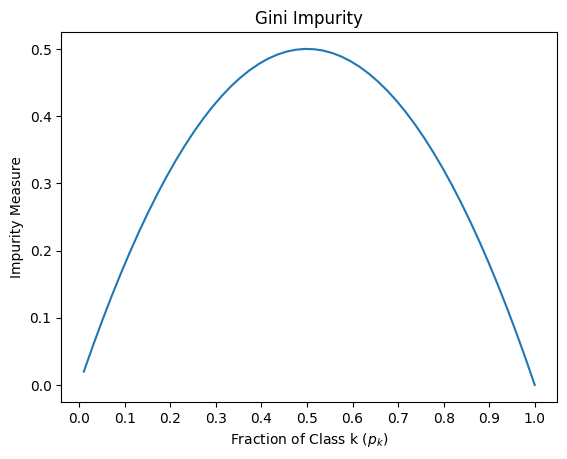

In [ ]:
#A figure is created to show Gini impurity measures
plt.figure()
x = np.linspace(0.01, 1)
y = 1 - (x * x) - (1 - x)*(1 - x)
plt.plot(x,y)
plt.title('Gini Impurity')
plt.xlabel("Fraction of Class k ($p_k$)")
plt.ylabel("Impurity Measure")
plt.xticks(np.arange(0,1.1,0.1))

plt.show()


In [ ]:
# Defining a simple dataset
attribute_names =  ['love_math', 'love_art','love_english']
class_name = 'love_ai'
data ={
    'love_math' : ['yes', 'yes', 'no', 'no', 'yes', 'yes','no'],
    'love_art' : ['yes', 'no', 'yes', 'yes', 'yes', 'no', 'no'],
    'love_english' : ['no','no','yes','yes','yes','yes','yes'],
    'love_ai' : ['no','no','yes','yes','yes','no','no']}
df = pd.DataFrame (data, columns=data.keys())
print(df)

  love_math love_art love_english love_ai
0       yes      yes           no      no
1       yes       no           no      no
2        no      yes          yes     yes
3        no      yes          yes     yes
4       yes      yes          yes     yes
5       yes       no          yes      no
6        no       no          yes      no


In [ ]:
# STEP 1: Calculate entire gini(D)
def gini_impurity(value_counts):
    n = value_counts.sum()
    p_sum = 0
    for key in value_counts.keys():
        p_sum = p_sum + (value_counts[key] / n) * (value_counts[key] / n)
    gini = 1 - p_sum
    return gini

In [ ]:
# Gini for Love AI
class_name = "love_ai"
class_value_counts = df[class_name].value_counts()
print(f'Number of samples in each class is:\n{class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'\nGini Impurity of the class is {gini_class:.3f}')

Number of samples in each class is:
love_ai
no     4
yes    3
Name: count, dtype: int64

Gini Impurity of the class is 0.490


In [ ]:
# Calculating  gini impurity for each condition
def gini_for_each_condition(attribute_name):
    attribute_values = df[attribute_name].value_counts()
    gini_A = 0
    for key in attribute_values.keys():
        df_k = df[class_name][df[attribute_name] == key].value_counts()
        n_k = attribute_values[key]
        n = df.shape[0]
        gini_A += (n_k / n) * gini_impurity(df_k)
    return gini_A

gini_attiribute ={}
for key in attribute_names:
    gini_attiribute[key] = gini_for_each_condition(key)
    print(f'Gini for {key} is {gini_attiribute[key]:.3f}')

Gini for love_math is 0.405
Gini for love_art is 0.214
Gini for love_english is 0.343


In [ ]:
# STEP 3:
# Compute Gini gain values to find the best split
# An attribute has maximum Gini gain is selected for splitting.

min_value = min(gini_attiribute.values())
print('The minimum value of Gini Impurity : {0:.3} '.format(min_value))
print('The maximum value of Gini Gain     : {0:.3} '.format(1-min_value))

selected_attribute = min(gini_attiribute.keys())
print('The selected attiribute is: ', selected_attribute)

The minimum value of Gini Impurity : 0.214 
The maximum value of Gini Gain     : 0.786 
The selected attiribute is:  love_art


In [ ]:
df = df[df[selected_attribute] == 'yes']
df

,love_math,love_art,love_english,love_ai
0,yes,yes,no,no
2,no,yes,yes,yes
3,no,yes,yes,yes
4,yes,yes,yes,yes


In [ ]:
df = df[df[selected_attribute] == 'yes']
df = df.drop(selected_attribute, axis = 1)

attribute_names.remove(selected_attribute)
class_name = 'love_ai'

gini_attiribute ={}
for key in attribute_names:
    gini_attiribute[key] = gini_for_each_condition(key)
    print(f'Gini for {key} is {gini_attiribute[key]:.3f}')

Gini for love_math is 0.250
Gini for love_english is 0.000


In [ ]:
# STEP 4:
# Compute Gini gain values to find the best split
# An attribute has maximum Gini gain is selected for splitting.
min_value = min(gini_attiribute.values())
print('The minimum value of Gini Impurity : {0:.3} '.format(min_value))
print('The maximum value of Gini Gain     : {0:.3} '.format(1-min_value))

selected_attribute = min(gini_attiribute.keys())
print('The selected attiribute is: ', selected_attribute)

The minimum value of Gini Impurity : 0.0 
The maximum value of Gini Gain     : 1.0 
The selected attiribute is:  love_english


In [ ]:
# Defining a simple dataset
attribute_names =  ['age', 'income','student', 'credit_rate']
class_name = 'default'
data1 ={
    'age' : ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior','middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age','middle_age', 'senior'],
    'income' : ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium','low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student' : ['no','no','no','no','yes','yes','yes','no','yes','yes','yes','no','yes','no'],
    'credit_rate' : ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair','excellent', 'excellent', 'fair', 'excellent'],
    'default' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes','yes', 'yes', 'yes', 'no']
}
df1 = pd.DataFrame (data1, columns=data1.keys())
print(df1)

           age  income student credit_rate default
0        youth    high      no        fair      no
1        youth    high      no   excellent      no
2   middle_age    high      no        fair     yes
3       senior  medium      no        fair     yes
4       senior     low     yes        fair     yes
5       senior     low     yes   excellent      no
6   middle_age     low     yes   excellent     yes
7        youth  medium      no        fair      no
8        youth     low     yes        fair     yes
9       senior  medium     yes        fair     yes
10       youth  medium     yes   excellent     yes
11  middle_age  medium      no   excellent     yes
12  middle_age    high     yes        fair     yes
13      senior  medium      no   excellent      no


In [ ]:
# STEP 1: Calculate gini(D)
def gini_impurity (value_counts):
    n = value_counts.sum()
    p_sum = 0
    for key in value_counts.keys():
        p_sum = p_sum  +  (value_counts[key] / n ) * (value_counts[key] / n )
    gini = 1 - p_sum
    return gini

class_value_counts = df1[class_name].value_counts()
print(f'Number of samples in each class is:\n{class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'\nGini Impurity of the class is {gini_class:.3f}')

Number of samples in each class is:
default
yes    9
no     5
Name: count, dtype: int64

Gini Impurity of the class is 0.459


In [ ]:
# STEP 2:
# Calculating  gini impurity for the attiributes
def gini_split_a(attribute_name):
    attribute_values = df1[attribute_name].value_counts()
    gini_A = 0
    for key in attribute_values.keys():
        df_k = df1[class_name][df1[attribute_name] == key].value_counts()
        n_k = attribute_values[key]
        n = df1.shape[0]
        gini_A = gini_A + (( n_k / n) * gini_impurity(df_k))
    return gini_A

gini_attiribute ={}
for key in attribute_names:
    gini_attiribute[key] = gini_split_a(key)
    print(f'Gini for {key} is {gini_attiribute[key]:.3f}')

Gini for age is 0.343
Gini for income is 0.440
Gini for student is 0.367
Gini for credit_rate is 0.429


In [ ]:
# STEP 3:
# Compute Gini gain values to find the best split
# An attribute has maximum Gini gain is selected for splitting.

min_value = min(gini_attiribute.values())
print('The minimum value of Gini Impurity : {0:.3} '.format(min_value))
print('The maximum value of Gini Gain     : {0:.3} '.format(1-min_value))

selected_attribute = min(gini_attiribute.keys())
print('The selected attiribute is: ', selected_attribute)

The minimum value of Gini Impurity : 0.343 
The maximum value of Gini Gain     : 0.657 
The selected attiribute is:  age


# **<font color = 'red'>2. Warmup 2</font>**

In [ ]:
import pandas as pd
import sklearn
from sklearn.datasets import load_iris
from sklearn import tree
from matplotlib import pyplot as plt

[Text(0.4, 0.8333333333333334, 'love_art <= 0.5\ngini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'love_english <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

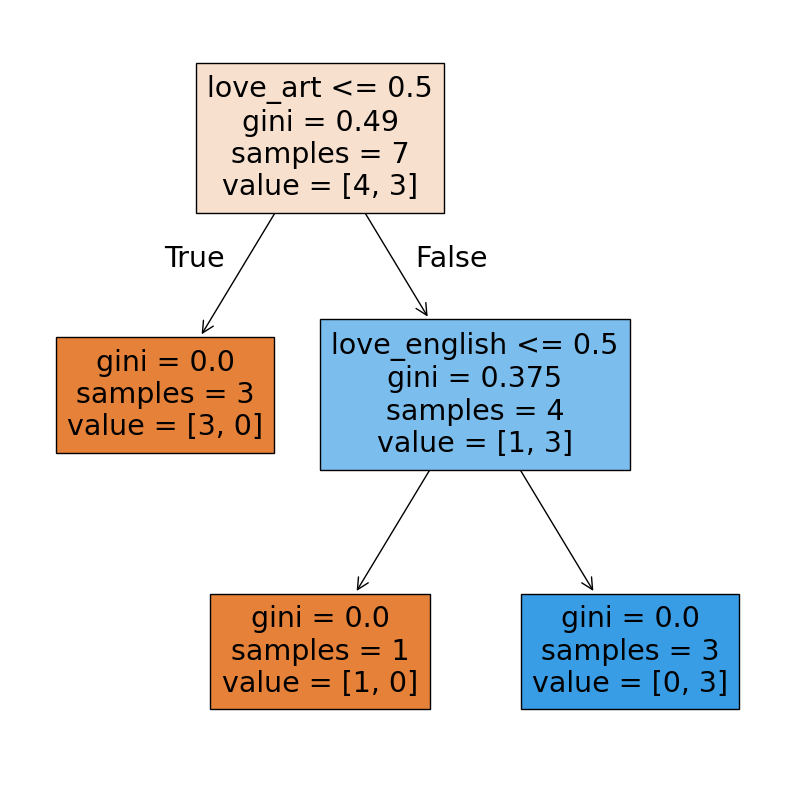

In [ ]:
# Defining a simple dataset
attribute_names =  ['love_math', 'love_art','love_english']
class_name = 'love_ai'
data ={
    'love_math' : ['yes', 'yes', 'no', 'no', 'yes', 'yes','no'],
    'love_art' : ['yes', 'no', 'yes', 'yes', 'yes', 'no', 'no'],
    'love_english' : ['no','no','yes','yes','yes','yes','yes'],
    'love_ai' : ['no','no','yes','yes','yes','no','no']}
df = pd.DataFrame (data, columns=data.keys())

classifier = tree.DecisionTreeClassifier(criterion="gini",
                                         max_depth=4, min_samples_leaf=1)
one_hot_data = pd.get_dummies(df[["love_math", "love_art", "love_english"]], drop_first=True)

X = one_hot_data.iloc[:, :].values
y = df["love_ai"].values

classifier.fit(X, y)

fig, ax = plt.subplots(figsize=(10,10))
tree.plot_tree(classifier,ax=ax, feature_names=["love_math", "love_art",
                                                "love_english"],
                                                 filled=True)

In [ ]:
result = classifier.predict([[1, 1, 0]])
print(result)

['no']


(150,)


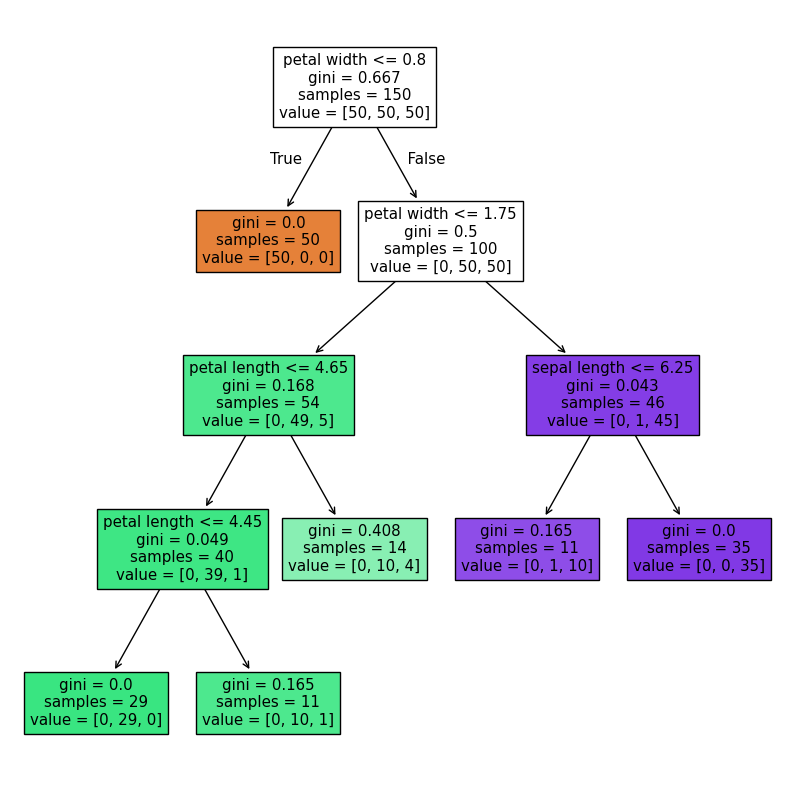

In [ ]:
from sklearn.datasets import load_iris
dataset = load_iris()
X = dataset.data
y = dataset.target
print(y.shape)
classifier = tree.DecisionTreeClassifier(criterion="gini",
                                         max_depth=4, min_samples_leaf=10)
classifier.fit(X,y)
fig, ax = plt.subplots(figsize=(10,10))
tree.plot_tree(classifier,ax=ax, feature_names=["sepal length", "sepal width",
                                                "petal length", "petal width"],
                                                 filled=True)
plt.show()

In [ ]:
result = classifier.predict([[0.3, 0.75, 4, 9]])
print(result)

[2]


# **<font color = 'red'>3. Credit card Fraud Detection</font>**

In [11]:
# importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [15]:
# load dataset
creditdata_df = pd.read_csv("/content/creditcard.csv")
print(f"Dataset Shape :-")
print(creditdata_df.shape)

Dataset Shape :-
(259432, 31)


In [16]:
creditdata_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259427,159111.0,-1.179649,-0.504119,1.484059,-0.508428,0.549946,-0.945195,0.176153,0.056981,0.503172,...,0.400470,0.819796,0.023627,-0.129637,0.153066,-0.556284,0.107515,0.166935,95.00,0.0
259428,159111.0,1.975655,-1.484272,-1.991903,-1.773126,1.304151,3.717924,-1.376639,0.944947,-0.016821,...,-0.161256,-0.694697,0.388977,0.671973,-0.473031,-0.561277,0.012325,-0.034432,97.09,0.0
259429,159112.0,1.676753,-0.593626,-1.345935,1.037221,-0.299915,-0.644091,0.053228,-0.227412,1.379008,...,0.282568,1.024251,-0.265934,0.002083,0.379770,0.055311,0.017531,-0.000965,162.98,0.0
259430,159112.0,2.064447,-1.102539,-0.419606,-0.455732,-1.161577,-0.075898,-1.163322,0.102897,0.054286,...,-0.143548,0.191926,0.153659,-0.393547,-0.361673,0.734349,-0.016425,-0.058744,24.50,0.0


In [17]:
print(creditdata_df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [18]:
creditdata_df = creditdata_df.dropna(subset=["Class"]).copy()

In [19]:
print(creditdata_df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [20]:
#view data
creditdata_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [21]:
# Check for data based on Class column value which indicates
# 1 => False & 0 => True
false = creditdata_df[creditdata_df['Class'] == 1]
true = creditdata_df[creditdata_df['Class'] == 0]
n = len(false) / float(len(true))
print(n)
print('False Detection : {}'.format(len(creditdata_df[creditdata_df['Class']==1])))
print('True Detection:{}'.format(len(creditdata_df[creditdata_df['Class']==0])),"\n")

0.0018188137164040778
False Detection : 471
True Detection:258960 



In [23]:
X = creditdata_df.drop(columns=["Class"])
y = creditdata_df['Class']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)

DecisionTreeClassifier()

In [25]:
y_pred = classifier.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy:", accuracy)

confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_mat)

Accuracy: 99.91327307418044
Confusion Matrix:
[[51775    20]
 [   25    67]]


In [27]:
#Precision
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision=precision_score(y_test, y_pred, pos_label=1)*100
print('\n Score Precision :\n',precision )

#Recall
# Recall = TP / (TP + FN)
recall=recall_score(y_test, y_pred, pos_label=1)*100
print("\n Recall Score :\n", recall)

fscore=f1_score(y_test, y_pred, pos_label=1)*100
print("\n F1 Score :\n", fscore)


 Score Precision :
 77.01149425287356

 Recall Score :
 72.82608695652173

 F1 Score :
 74.86033519553072


In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51795
         1.0       0.77      0.73      0.75        92

    accuracy                           1.00     51887
   macro avg       0.88      0.86      0.87     51887
weighted avg       1.00      1.00      1.00     51887



In [33]:
# Check model Overfitting
from sklearn.metrics import accuracy_score

y_pred_train = classifier.predict(X_train)

y_pred_test = classifier.predict(X_test)

print(f"Accuracy for Train:\n{accuracy_score(y_train, y_pred_train)}")
print(f"Accuracy for Train:\n{accuracy_score(y_test, y_pred_test)}")

Accuracy for Train:
1.0
Accuracy for Train:
0.9991327307418043


In [50]:
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Synthetic_Financial_datasets_log.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [51]:
# Chech Null and NaN
print(data.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [52]:
# Exploring transaction type
print(data.type.value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [53]:
type = data["type"].value_counts()
transactions = type.index
quantity = type.values

import plotly.express as px
figure = px.pie(data,
                values=quantity,
                names=transactions, hole = 0.5,
                title="Distribution of Transaction Type")
figure.show()

In [54]:
data["type"] = data["type"].map({"CASH_OUT": 1, "PAYMENT": 2,
                                 "CASH_IN": 3, "TRANSFER": 4,
                                 "DEBIT": 5})
data["isFraud"] = data["isFraud"].map({0: "No Fraud", 1: "Fraud"})
print(data.head())

   step  type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1     2   9839.64  C1231006815       170136.0       160296.36   
1     1     2   1864.28  C1666544295        21249.0        19384.72   
2     1     4    181.00  C1305486145          181.0            0.00   
3     1     1    181.00   C840083671          181.0            0.00   
4     1     2  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0  No Fraud               0  
1  M2044282225             0.0             0.0  No Fraud               0  
2   C553264065             0.0             0.0     Fraud               0  
3    C38997010         21182.0             0.0     Fraud               0  
4  M1230701703             0.0             0.0  No Fraud               0  


In [56]:
# splitting the data
from sklearn.model_selection import train_test_split
x = np.array(data[["type", "amount", "oldbalanceOrg", "newbalanceOrig"]])
y = np.array(data[["isFraud"]])

In [57]:
print(x)

[[2.00000000e+00 9.83964000e+03 1.70136000e+05 1.60296360e+05]
 [2.00000000e+00 1.86428000e+03 2.12490000e+04 1.93847200e+04]
 [4.00000000e+00 1.81000000e+02 1.81000000e+02 0.00000000e+00]
 ...
 [1.00000000e+00 6.31140928e+06 6.31140928e+06 0.00000000e+00]
 [4.00000000e+00 8.50002520e+05 8.50002520e+05 0.00000000e+00]
 [1.00000000e+00 8.50002520e+05 8.50002520e+05 0.00000000e+00]]


In [58]:
# training a machine learning model
from sklearn.tree import DecisionTreeClassifier
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.10, random_state=42)
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)
print(model.score(xtest, ytest))

0.9997343861491021


In [59]:
# prediction
#features = [type, amount, oldbalanceOrg, newbalanceOrig]
features = np.array([[4, 9000.60, 9000.60, 0.0]])
print(model.predict(features))

['Fraud']
